# AL-2002: Artificial Intelligence Lab
## Lab 12 — Evaluation Metrics for ML Models
**National University of Computer and Emerging Sciences — FAST-NU, Lahore**

---

> **Instructions:**
> - In **Question 1 Part A**, implement all metrics from scratch using **only NumPy** — do not use `sklearn`.
> - Write your answers in the provided code cells. Add new cells only if needed.
> - Written answers go in the designated Markdown cells.

---

## Student Information

In [1]:
Name        = "Zohaib Hussain"   # Write your full name here
Roll_Number = "23L-3087"   # Write your roll number here

print(f"Name        : {Name}")
print(f"Roll Number : {Roll_Number}")

Name        : Zohaib Hussain
Roll Number : 23L-3087


## 🌫️ Question 1 — Lahore Smog Watch: AQI Prediction

---

Every November, Lahore disappears into a thick blanket of smog — a crisis driven by crop burning, vehicle emissions, and industrial pollution. The Punjab Safe Cities Authority is piloting an AI system to **predict the Air Quality Index (AQI)** a day in advance, so that school closures, outdoor bans, and emergency health advisories can be issued proactively.

You have been given the model's predictions for **5 consecutive smog-season days** alongside the actual AQI readings recorded at the Gulberg monitoring station:

| Day | Actual AQI | Predicted AQI |
|-----|------------|---------------|
| 1   | 310        | 295           |
| 2   | 275        | 290           |
| 3   | 420        | 400           |
| 4   | 190        | 210           |
| 5   | 350        | 340           |

> **AQI Reference:** 0–50 Good · 51–100 Moderate · 101–150 Unhealthy for Sensitive Groups · 151–200 Unhealthy · 201–300 Very Unhealthy · **301+ Hazardous**

---

### Part A — Manual Implementation *(No sklearn allowed)*

Using **only NumPy**, implement the following from scratch:
1. Mean Absolute Error (MAE)
2. Mean Squared Error (MSE)
3. Root Mean Squared Error (RMSE)
4. R-squared (R²) Score

In [3]:
import numpy as np

y_true = np.array([310, 275, 420, 190, 350])  # Actual AQI readings
y_pred = np.array([295, 290, 400, 210, 340])  # Model predictions

# -----------------------------------------------
# Part A: Implement from scratch (No sklearn)
# -----------------------------------------------
n = len(y_pred)
# 1. MAE
mae = np.sum([ abs(y_true[i] - y_pred[i]) for i in range(n) ]) / n

# 2. MSE
mse = np.sum([ (y_true[i] - y_pred[i]) ** 2 for i in range(n) ]) / n

# 3. RMSE
rmse = np.sqrt(mse)

# 4. R² Score
mean = np.sum(y_true) / n
nume = np.sum([ (y_true[i] - y_pred[i]) ** 2 for i in range(n) ])
denom = np.sum([ (y - mean) ** 2 for y in y_true ])
r2 = 1 - (nume / denom)

fmt = lambda v: f"{v:.4f}" if v is not None else "None"
print(f"MAE  : {fmt(mae)}")
print(f"MSE  : {fmt(mse)}")
print(f"RMSE : {fmt(rmse)}")
print(f"R²   : {fmt(r2)}")

MAE  : 16.0000
MSE  : 270.0000
RMSE : 16.4317
R²   : 0.9540


### Part B — Validation with sklearn

Verify all four of your Part A results using the appropriate `sklearn.metrics` functions.  
Your manually computed values must **match** the sklearn output.

In [4]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_true = np.array([310, 275, 420, 190, 350])  # Actual AQI readings
y_pred = np.array([295, 290, 400, 210, 340])  # Model predictions

fmt = lambda v: f"{v:.4f}" if v is not None else "None"

# Verify MAE
mae_sk = mean_absolute_error(y_true, y_pred)
print(f"sklearn MAE  : {fmt(mae_sk)}")

# Verify MSE
mse_sk = mean_squared_error(y_true, y_pred)
print(f"sklearn MSE  : {fmt(mse_sk)}")

# Verify RMSE  (Hint: sklearn has no direct rmse function — use np.sqrt(mean_squared_error(...)))
rmse_sk = np.sqrt(mse_sk)
print(f"sklearn RMSE : {fmt(rmse_sk)}")

# Verify R²
r2_sk = r2_score(y_true, y_pred)
print(f"sklearn R²   : {fmt(r2_sk)}")

sklearn MAE  : 16.0000
sklearn MSE  : 270.0000
sklearn RMSE : 16.4317
sklearn R²   : 0.9540


### Part C — Interpretation

Answer the following in **3–5 lines each** in the Markdown cell below:

1. Compare your computed **RMSE** and **MAE** values. In this smog-alert context, which metric should the Punjab Safe Cities Authority rely on more — and why?  
*(Hint: think about what a large single-day prediction error could mean for public health decisions.)*

2. Based on your computed **R² score**, does this model seem reliable enough to drive real government decisions like school closures? What real-world limitations might still exist despite a high R²?

**Answer C.1:**  
*as RMSE and MSE are squares of errors, so they tend to punish large values more. Therefore, Punjab Safe Cities Authority must rely on MAE.*

**Answer C.2:**  
*r2_score close of 0.95 tells that 95% of variance of dependent variable e.g(y) is predictable by independent variables of model e.g(x).\
Therefore, model is enough reliable for real world decisions. But real-world limitation might exiests as 5% of values are still unpredictable*

---

## 🏏 Question 2 — PSL Match Win Predictor

---

A Lahore-based fantasy cricket startup is building a **match outcome predictor for the Pakistan Super League (PSL)**. Their ML model takes pre-match features — pitch report, toss result, team form, and head-to-head record — and predicts whether the home team will win.

- **1** = Home Team Wins  
- **0** = Home Team Loses

The model was evaluated on **10 PSL matches** with the following results:

| Match | Actual | Predicted | Win Probability |
|-------|--------|-----------|-----------------|
| 1     | 1      | 1         | 0.82            |
| 2     | 0      | 1         | 0.55            |
| 3     | 1      | 0         | 0.38            |
| 4     | 1      | 1         | 0.71            |
| 5     | 0      | 0         | 0.25            |
| 6     | 1      | 1         | 0.91            |
| 7     | 0      | 0         | 0.35            |
| 8     | 0      | 1         | 0.60            |
| 9     | 1      | 1         | 0.88            |
| 10    | 0      | 0         | 0.30            |

---

### Part A — Confusion Matrix & Metrics

1. Compute and **visualize** the confusion matrix as a labeled heatmap using `seaborn`.
2. From the confusion matrix, **manually extract** TP, TN, FP, FN and calculate Precision, Recall, and F1-score — show your working in comments.
3. Verify using `sklearn`'s `classification_report`.

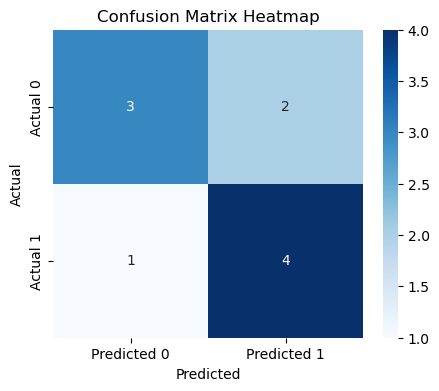

Manual Precision : 0.6666666666666666
Manual Recall    : 0.8
Manual F1 Score  : 0.7272727272727272
              precision    recall  f1-score   support

           0       0.75      0.60      0.67         5
           1       0.67      0.80      0.73         5

    accuracy                           0.70        10
   macro avg       0.71      0.70      0.70        10
weighted avg       0.71      0.70      0.70        10



In [11]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

y_true  = [1, 0, 1, 1, 0, 1, 0, 0, 1, 0]          # Actual match outcomes
y_pred  = [1, 1, 0, 1, 0, 1, 0, 1, 1, 0]          # Predicted outcomes
y_proba = [0.82, 0.55, 0.38, 0.71, 0.25,
           0.91, 0.35, 0.60, 0.88, 0.30]           # Win probabilities

# -----------------------------------------------
# 1. Confusion Matrix Heatmap
# -----------------------------------------------
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
xticklabels=['Predicted 0','Predicted 1'], yticklabels=['Actual 0','Actual 1'])
plt.title('Confusion Matrix Heatmap')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()


# -----------------------------------------------
# 2. Manual Calculation — read the TP, TN, FP, FN values from the
#    confusion matrix output above, fill them in the comments below,
#    then use those numbers to compute Precision, Recall, and F1.
#    Note: sklearn cm layout is [[TN, FP], [FN, TP]]
# -----------------------------------------------

# TP (Predicted Win,  Actually Won)  = 
# TN (Predicted Loss, Actually Lost) = 
# FP (Predicted Win,  Actually Lost) = 
# FN (Predicted Loss, Actually Won)  = 

# Precision = TP / (TP + FP) = 
# Recall    = TP / (TP + FN) = 
# F1        = 2 * (Precision * Recall) / (Precision + Recall) = 
n = len(y_pred)
TP = len([1 for i, y in enumerate(y_pred) if y and y_true[i]])
TN = len([1 for i, y in enumerate(y_pred) if not y and not y_true[i]])
FP = len([1 for i, y in enumerate(y_pred) if y and not y_true[i]])
FN = len([1 for i, y in enumerate(y_pred) if not y and y_true[i]])


precision_manual = TP / (TP + FP)  
recall_manual = TP / (TP + FN)  
f1_manual = 2 * (precision_manual * recall_manual) / (precision_manual + recall_manual) 

print(f"Manual Precision : {precision_manual}")
print(f"Manual Recall    : {recall_manual}")
print(f"Manual F1 Score  : {f1_manual}")

# -----------------------------------------------
# 3. Verify with sklearn — print the full classification_report below
# -----------------------------------------------
print(classification_report(y_true, y_pred))

### Part B — ROC Curve & AUC Score

Using `y_proba`:
1. Compute and print the **AUC Score**.
2. Plot the **ROC Curve** with the AUC value shown in the legend.
3. Include the **random baseline** (diagonal dashed red line) for reference.

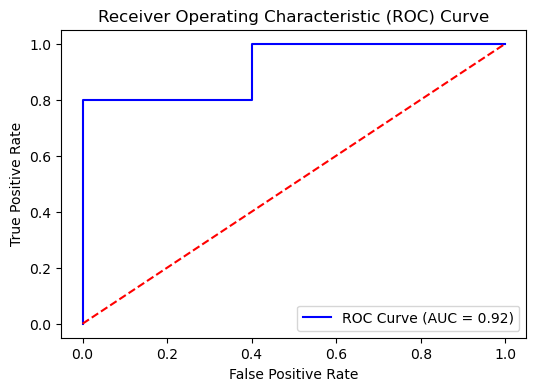

In [17]:
from sklearn.metrics import roc_curve, roc_auc_score

y_true  = [1, 0, 1, 1, 0, 1, 0, 0, 1, 0]          # Actual match outcomes
y_proba = [0.82, 0.55, 0.38, 0.71, 0.25,
           0.91, 0.35, 0.60, 0.88, 0.30]           # Win probabilities

# 1. Compute AUC Score
roc_auc = roc_auc_score(y_true, y_proba)

# 2 & 3. Plot ROC Curve with baseline
fpr, tpr, thresholds = roc_curve(y_true, y_proba)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0,1], [0,1], color='red', linestyle='--')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

### Part C — Critical Thinking

The startup's product manager reviews the results and says:

> *"We correctly predicted 7 out of 10 matches. 70% accuracy — let's ship it to our PSL fantasy users!"*

Answer the following in **3–5 lines each** in the Markdown cell below:

1. Using your computed Precision and Recall values, explain why **70% accuracy alone does not tell the full story**. What does accuracy fail to capture here?

2. For a **PSL fantasy cricket platform**, which matters more to a user — **Precision** or **Recall** — and why?  
*(Think: what happens when the model confidently predicts a win that turns out to be a loss, versus when it misses a win entirely?)*

3. Compare your computed **Precision and Recall values**. What does this trade-off mean practically for PSL fans relying on this app to pick their fantasy squads?

**Answer C.1 — Why accuracy is not enough here:**  
*Accuracy alone is not enough because accuracy can be misleading if we have unbalanced dataset. It only tells correct no predections and ignore the false predictions.\
Imagine if we have two classes one with very small representation, and model always predict class with more representation. Here accuracy is high but model is not good.*

**Answer C.2 — Precision vs. Recall: which matters more for a fantasy cricket user?**  
*In this case, Precision matters more. If the model predicts that a team will win and it loses, users of fantasy cricket may pick wrong players and lose points. While not getting a win is less harmful than being confidently wrong about a win.*

**Answer C.3 — What does the Precision vs. Recall trade-off mean for PSL fans?**  
*If Precision is greater Recall, predictions are safer but miss some good opportunities due to less recall. If Recall is greater Precision, users get more winning chances but also more wrong picks due to less precision. For PSL fans, this trade-off means balancing confidence vs coverage and whether to play safe or take risk*

---
### ✅ End of Lab 12
_Ensure all cells are executed and all outputs are visible before submitting your notebook._

---
> ⚠️ **Before Submitting:**  
> Rename this file to your **Roll Number** before uploading.  
> Example: `L221234.ipynb`  
> Submissions not following this format will **not** be accepted.